# Implementation of k nearest neighbor, nested cross-validation and evaluation metrics with iris data set

## Python version used for this notebook

In order to run this notebook, please use at least Python version 3.6. as I am using f-strings in my code. 
I am using Python version 3.7.5 to run this notebook. Thanks!

In [1]:
import platform
display(platform.python_version()) #display python version

'3.7.5'

In [2]:
#importing dependencies

# set matplotlib backend to inline
%matplotlib inline 

from sklearn import datasets # import datasets
import numpy as np # import numpy
import matplotlib.pyplot as plt # import plots
import pandas as pd

# set the seed for the random number generator
mySeed=7654321

# load data
iris = datasets.load_iris() # load iris data set 
X = iris.data # get features
y = iris.target # get y values

In [4]:
#description of iris data set
print(iris.DESCR )

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

## 1. Exploratory Data Analysis

Creation of multiple subplots in a grid where each row and each column in the grid represent one of the different 4 features of the iris dataset. 

In [7]:
# define plotting function

def myplotGrid(X, y):
    """
    Plots all possible feature combination pairs of the iris dataset as subplots in a 4x4 grid.
    Each row and each column in the grid represent one of the different 4 features of the iris dataset. 
    Plots in the same row have the same feature on the y-axis. Plots in the same column have the same feature on the 
    x-axis. Plots in the main diagonal are histograms showing the frequency distribution of the single feature of 
    that row. Each off-diagonal subplot shows the interaction between two features. Given subplots in a single row, 
    the same feature on the y-axis is plotted sequentially against the other three features on the x-axis. 

    Parameters
    ----------
    X : numpy.array
        Dataset in the form of 2-dimensional array that must have four feature columns, number of rows is not 
        restricted. Each column represents a different feature (variable) and each row a different observation. 
        This dataset should not contain labels.
    y : numpy.array
        1-dimensional array which contains the labels for dataset X. In this array, each value at index k 
        represents the label for the row k in dataset X. Array length must be equal to number of rows in training_data.
    
    Returns
    -------
    prints matplot subplots in a 4 by 4 grid
    """
    
    #setting size of subplot grid
    fig = plt.figure(figsize=(12,12))
    
    #creating variable num_subplot to create different subplots in grid
    num_subplot=1
    
    #iterating over all rows in grid
    for row in range(4):
        #iterating over all columns in the current row
        for column in range(4):
            
            #create new subplot
            ax = fig.add_subplot(4,4,num_subplot) 
            
            #displaying feature names on x-axis of all subplots in last row of grid
            if row ==3:
                ax.set_xlabel(iris.feature_names[column])

            #displaying feature names on y-axis of all subplots in first column of grid
            if column==0:
                ax.set_ylabel(iris.feature_names[row])
            
            #if number of column and row are equal this corresponds to main diagonal in grid. plot univariate histogram
            if row ==column:
                ax.hist(X[:,row])
                num_subplot +=1
            
            #displaying only one legend for all subplots by calling plt.legend only one time for one subplot
            #choosing the fourth subplot of the third row to build the legend
            #constructing one scatter plot per class by separating each 50 class samples with array slicing
            #which allows plt.legend to automatically identify the three groups
            #using html hex string as colors;
            elif row == 2 and column == 3: 
                scat1 = ax.scatter(X[:50, column], X[:50, row], s=30, edgecolor='black', linewidth=0.2,
                           c='#1ABC9C', alpha=0.8)
                scat2 = ax.scatter(X[50:100, column], X[50:100, row], s=30, edgecolor='black', linewidth=0.2,
                           c='#E67E22', alpha=0.8)
                scat3 = ax.scatter(X[100:, column], X[100:, row],  s=30, edgecolor='black', linewidth=0.2,
                           c='#7FB3D5', alpha=0.8)
                num_subplot +=1
                
                #calling plt.legend only once to avoid multiple legends, iris.target_names stores three species names
                plt.legend(iris.target_names,loc=(1,0.5),title='species')
            
            #in all other cases: plot scatter plot of respective feature combination. 
            #constructing one scatter plot per class using html hex string as colors
            else:
                scat1 = ax.scatter(X[:50, column], X[:50, row], s=30, edgecolor='black', linewidth=0.2,
                           c='#1ABC9C', alpha=0.8)
                scat2 = ax.scatter(X[50:100, column], X[50:100, row], s=30, edgecolor='black', linewidth=0.2,
                           c='#E67E22', alpha=0.8)
                scat3 = ax.scatter(X[100:, column], X[100:, row],  s=30, edgecolor='black', linewidth=0.2,
                           c='#7FB3D5', alpha=0.8)
                num_subplot +=1

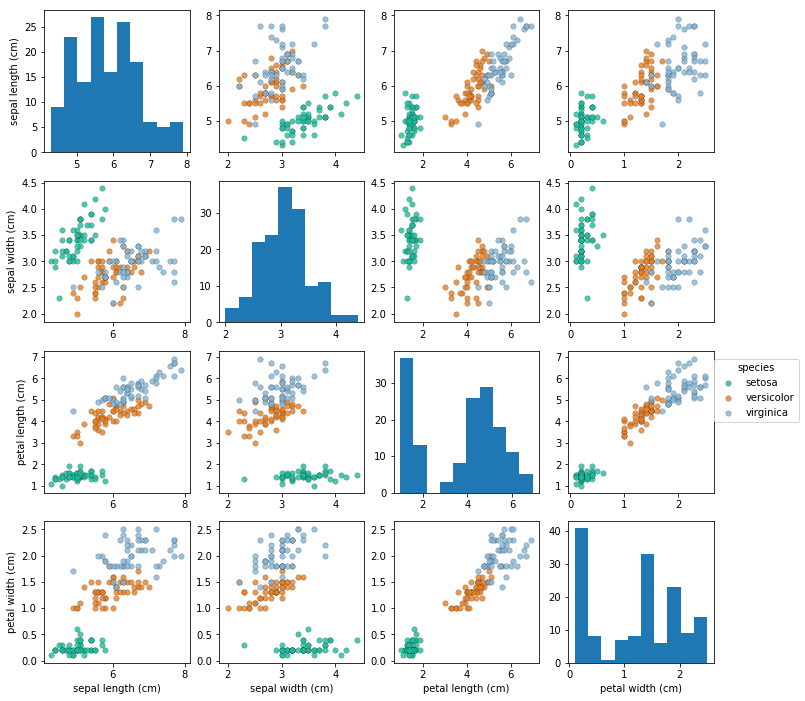

In [8]:
# run the plotting function
myplotGrid(X,y)

## 2. Function for k nearest neighbor

### 2.1 Helper functions for distance metrics

Implementation of euclidean, manhattan and chebyshev distance metrics.

* https://en.wikipedia.org/wiki/Euclidean_distance
* https://en.wikipedia.org/wiki/Taxicab_geometry
* https://en.wikipedia.org/wiki/Chebyshev_distance


In [9]:
def euclidean_distance(training_point, test_point):
    """
    Calculates euclidean distance between two data points.
    The squared differences between corresponding feature combinations of a data point from training data and a 
    data point from test data are added and the square root of this sum returned.

    Parameters
    ----------
    training_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to test_point.
    test_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to training_point.
    
    Returns
    -------
    numpy.float64
        Square root of sum of squared differences between corresponding features of two data points
    """
    #variable to store sum of squared difference 
    eucl_distance_sum = 0
    
    #iterating over each corresponding feature of point from training set and test set
    #calculating sum of squared differences 
    for num in range(len(training_point)):
        eucl_distance_sum += ((training_point[num] - test_point[num])**2)
    
    #returns square root of sum of squared differences between corresponding features of two data points
    return np.sqrt(eucl_distance_sum)

def manhattan_distance(training_point, test_point):
    """
    Calculates manhattan distance between two data points.
    The absolute values of the differences between corresponding feature combinations of a data point from training 
    data and a data point from test data are added and this sum returned.

    Parameters
    ----------
    training_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to test_point.
    test_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to training_point.
    
    Returns
    -------
    numpy.float64
        Sum of absolute values of differences between corresponding features of two data points
    """
    #variable to store sum of absolute values
    man_distance_sum = 0
    
    #iterating over each corresponding feature of point from training set and test set, adding absolute value 
    #of difference to man_distance_sum
    for num in range(len(training_point)):
        man_distance_sum += abs(training_point[num] - test_point[num])
    
    #return sum of absolute values
    return man_distance_sum
    

def chebyshev_distance(training_point, test_point):
    """
    Calculates chebyshev distance between two data points.
    The absolute values of the differences between corresponding feature combinations of a data point from training 
    data and a data point from test data are calculated. The different absolute values are compared and the 
    largest value is returned.

    Parameters
    ----------
    training_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to test_point.
    test_point : numpy.array
        1-dimensional array with n feature variables. Array length must be equal to training_point.
    
    Returns
    -------
    numpy.float64
        Largest absolute value of differences between corresponding features of two data points
    """
    
    #creating list to store all absolute values of differences between features
    distance_list = []
    
    #iterating over each corresponding feature of point from training set and test set, appending absolute value 
    #of difference to distance_list
    for num in range(len(training_point)):
        distance_list.append(abs(training_point[num] - test_point[num]))
    
    #returning largest value in distance_list by using max function 
    return max(distance_list)


### 2.1 k nearest neighbor function

Implementing version of k nearest neighbors, parameters include numbers of neighbors to determine classification by majority vote and desired distance function.

In [10]:
# mykNN code
def mykNN(training_data, training_output, testing_data, distance="euclidean", k_neighbor=7):
    """
    k-nearest neighbor algorithm that classifies data points from a test data set based on vote of nearest 
    data points (neighbors) from training data set. 
    To determine the nearest neighbors, three different distance metrics can be used (Euclidean, Manhattan, Chebyshev)
    and different number of nearest neighbors can be specified.
    

    Parameters
    ----------
    training_data : numpy.array
        2-dimensional array with number of columns corresponding to number of features, number of rows corresponding 
        to number of observations. Used for training for kNN.
    training_output : numpy.array
        1-dimensional array which contains the labels for training_data. In this array, each value at index k 
        represents the label for the row k in training_data. Array length must be equal to number of rows in 
        training_data. Used for training for kNN.
    testing_data : numpy.array
        2-dimensional array with number of columns corresponding to number of features, number of rows corresponding 
        to number of observations. kNN has to predict classes for each observation.
    distance     : {euclidean, manhattan, chebyshev}, default = "euclidean"
        Distance calculation used by kNN to determine distance between data point from training_data and data point
        from testing_data.
            "euclidean" will use Euclidean distance
            "manhattan" will use Manhattan distance
            "chebyshev" will use Chebyshev distance
    k_neighbor   : int, default = 7
        Number of nearest neigbors that vote on classification of data point from testing_data
    
    Returns
    -------
    numpy.ndarray
        Predicted class for each testing data point.
    """
    
    #verifying input data is in the form of numpy array
    assert any([isinstance(training_data,np.ndarray), isinstance(training_output,np.ndarray),
                isinstance(testing_data,np.ndarray)])
    
    #making sure that testing data is two-dimensional, required for loop (for test_point in testing_data)
    assert len(testing_data.shape) >=2, "Training data must be of type numpy array and have at least two dimensions."
    
    #verifying k_neighbor is positive integer 
    assert k_neighbor>0, "Please provide a positive integer for k_neighbor (e.g., k_neighbor=5)."
    
    #checking for correct spelling of distance_type, communicate correct spelling + options to user
    distance_types = ["euclidean","manhattan","chebyshev"]
    assert distance in distance_types,f"""The typed distance metric is not supported or was incorrectly spelled. 
            Please choose one of the following: {distance_types}."""
    
    #transforming distance parameter to corresponding function call
    if distance == "manhattan":
        distance_metric = manhattan_distance
    elif distance == "chebyshev":
        distance_metric = chebyshev_distance
    else:
        distance_metric = euclidean_distance
    
    #creating list for all predictions for test data which will be transformed to np.array and returned as output
    predicted_output = []
    
    #iterating over all data points in testing_data
    for test_point in testing_data:
        #create dictionary to store all distances between test data point and all data points from training_data
        train_test_distance = {}
        #create list to store classes of nearest neighbors
        decision_list = []
        
        #iterating over all training points calculating distance between each training point and test point
        #storing the distance in dictionary train_test_distance
        for num, training_point in enumerate(training_data):
            train_test_distance[num]= distance_metric(training_point,test_point)
        
        #sorting dictionary train_test_distance by values in ascending order, start iteration over sorted values
        for i in sorted(train_test_distance.items(),key = lambda x:x[1]):
            
            #appending class of nearest neighbors to decision_list, stopping to append when number of parameter
            #k_neighbor is reached (break out of loop)
            decision_list.append(training_output[i[0]])
            if len(decision_list) == k_neighbor:
                break
        
        #creating dictionary decision_dict to count occurances of different classes in list decision_list
        decision_dict = {}
        #iterating over all items in decision_list, if item is already present in dict, raise value by one, else
        #create new key value pair with key being number of class and value set to 1
        for i in decision_list:
            if i in decision_dict:
                decision_dict[i] +=1
            else:
                decision_dict[i] =1
        
        #using max()function to determine key with highest value in decision_dict (key corresponds to class)
        #append to predicted_output list
        predicted_output.append(max(decision_dict, key = lambda key:decision_dict[key]))
    
    #transforming list predicted_output into numpy array and returning this array
    return np.array(predicted_output)

## Function to calculate confusion matrix and performance metrics

Function calculates and prints recall, precision, f1-score, accuracy and confusion matrix with overall accuracy.

In [11]:
# confusion matrix code
def confusion_matrix(ground_truth,predicted,desired_output="all"):
    """
    Comparison of predicted labels of classifier versus ground truth labels and calculation of performance metrics.
    Displaying different classifier evaluation methods (e.g., confusion matrix, accuracy) of predicted labels.    

    Parameters
    ----------
    ground_truth : numpy.array
        1-dimensional array which contain the ground truth labels for testing data set
    predicted    : numpy.array
        1-dimensional array which contain the predicted labels for testing data set as determined by classifier
        Length of array ground_truth must be equal to length of array predicted
    desired_output  : {plain_matrix, confusion, all}
        Determine output of function
            "plain_matrix" will return the confusion matrix as a numpy array
            "confusion" will print the confusion matrix
            "all" will print the confusion matrix together with classification report (class-relative precision 
            and recall, accuracy) 
    Returns
    -------
    print output or numpy.array
        Depending on parameter desired_output either returns print statement (displaying confusion matrix or confusion
         matrix together with classification report) or confusion matrix in form of numpy array.
    """
    #defining dimensions of confusion matrix based on number of classes
    dimension = len(np.unique(ground_truth))
    
    #defining confusion matrix: squared matrix with zero with type integers (predicted class is int and not float)
    matrix = np.zeros([dimension,dimension], dtype=int)
    
    #iterating over all values in ground truth array, when equal to predicted add 1 to diagonal of respective class
    #in confusion matrix, else add 1 to row of ground truth class and column of predicted class
    for num, i in enumerate(ground_truth):
        if ground_truth[num] == predicted[num]:
            matrix[i][i] += 1
        else:
            matrix[i][predicted[num]] += 1
    
    #accuracy: dividing sum of values in main diagonal (np.trace) by sum of all elements in array (np.sum)
    accuracy = round(np.trace(matrix)/np.sum(matrix),3)
    
    #creating list of tuples to append metrics of interest
    class_report = [('Class','Precision','Recall','F1-score'),('','','','')]
    
    #returns list of sums for values in each row in confusion matrix (axis = 1)
    row_sum = matrix.sum(axis=1)
    
    #returns list of sums for values in each column in confusion matrix (axis = 0)
    col_sum = matrix.sum(axis=0)
    
    #iterates over all values in main diagonal to determine class-relative precision, recall, f1 score
    for class_num, dia_value in enumerate(np.diagonal(matrix)):
        
        #to avoid division by zero
        if col_sum[class_num] == 0:
            precision = 0
        #calculate class-relative precision
        else:
            precision = (dia_value/col_sum[class_num])
        
        #to avoid division by zero
        if row_sum[class_num] == 0:
            recall = 0
        #calculate class-relative recall
        else:
            recall = (dia_value/row_sum[class_num])
        
        #to avoid division by zero
        if ((recall+precision) == 0): 
            f1_score = 0
        #calculate class-relative f1 score
        else:
            f1_score = ((2*(recall*precision))/(recall+precision))
        #appending    
        class_report.append((class_num,round(precision,2),round(recall,2),round(f1_score,2)))
    
    #depending on parameter "desired output" in function call, defining output for function return
    
    #return only confusion matrix array
    if desired_output == "plain_matrix":
        output = matrix
    #return printing of confusion matrix 
    elif desired_output == "confusion":
        def print_matrix():
            print(f"Confusion matrix: ")
            print(matrix)
            print("--------------------------------")    
        output = print_matrix()
    #return printing of confusion matrix and classification report    
    else:
        def print_class_report(class_report):
            print(f"Confusion matrix: ")
            print(matrix)
            print("--------------------------------")
            #using f string formatting with padding 
            for species in class_report:
                print(f"{species[0]:{5}} {species[1]:{8}} {species[2]:{7}} {species[3]:{7}}")
            print("--------------------------------")
            print(f"Accuracy: {accuracy:{20}}")
        output = print_class_report(class_report)
    
    #depending on desired_output parameter returns either print output or numpy.array
    return output


### Comparing my own classifier of k-NN with the sklearn version of k-NN
Now I would like to test my kNN classifier against the sklearn kNN classifier. I will use sklearn for splitting the data into training and testing data, use both classifiers and then use my evaluation function to establish a confusion matrix and classification reports for both classifiers. 

In [12]:
#importing sklearn train test split
from sklearn.model_selection import train_test_split

#performing train test split by using sklearn function, using 33% of data as test size
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=mySeed)

In [13]:
#calling my kNN function to predict classes for test data, using distance metric euclidean and numbers of nearest 
#neighbors of 10
y_ = mykNN(training_data=X_train, training_output=y_train, testing_data=X_test, distance="euclidean", 
                  k_neighbor=10)

In [ ]:
#importing sklearn kNN classifier
from sklearn.neighbors import KNeighborsClassifier
#define classifier with distance metric euclidean and numbers of nearest neighbors of 10
sklearn_knn=KNeighborsClassifier(n_neighbors=10, metric='euclidean')
#fit the sklearn classifier to training data
sklearn_knn.fit(X_train,y_train)
#using sklearn classifier to predict classes of test data
sklearn_pred = sklearn_knn.predict(X_test)

In [24]:
#printing result of my own kNN classifier
print("--------------------------------\n my kNN classifier:")
print()
confusion_matrix(y_test,y_)
print()
print()

#printing result of sklearn kNN classifier
print("--------------------------------\n sklearn classifier:")
print()
confusion_matrix(y_test,sklearn_pred)

--------------------------------
 my kNN classifier:

Confusion matrix: 
[[15  0  0]
 [ 0 18  1]
 [ 0  0 16]]
--------------------------------
Class Precision Recall  F1-score
                              
    0      1.0     1.0     1.0
    1      1.0    0.95    0.97
    2     0.94     1.0    0.97
--------------------------------
Accuracy:                 0.98


--------------------------------
 sklearn classifier:

Confusion matrix: 
[[15  0  0]
 [ 0 18  1]
 [ 0  0 16]]
--------------------------------
Class Precision Recall  F1-score
                              
    0      1.0     1.0     1.0
    1      1.0    0.95    0.97
    2     0.94     1.0    0.97
--------------------------------
Accuracy:                 0.98


My own implementation of kNN gets the exact same accuracy and confusion matrix as the sklearn implementation of kNN when distance is set to "euclidean" and number of neighbors set to 10.


## 4. Function for nested cross-validation 

The following code performs nested cross-validation and returns an array with summary statistics per fold with a calculation of total accuracy. In addition, this function returns the confusion matrices of each outer fold in a list.

In [15]:
#importing product function for cartesian product of selected hyperparameters
from itertools import product  

    
def myNestedCrossVal(data_feature, data_label, number_folds=5, k_neighbor=list(range(1,11)),
                     distance = ['euclidean','chebyshev','manhattan'], random_seed = mySeed,
                     type_confusion = "confusion", validation_sets_per_fold = 2):
    """
    
    Nested cross-validation algorithm that trains and evaluates performance of different hyperparameter combinations 
    for k nearest neighbor algorithm on training data, chooses most successful hyperparameters for validation set
    and evaluates the performance of the same hyperparameter combination on test set. 
    The data is split into equally-sized folds, and iterates over these folds (outer loop). In each iteration, 
    a different fold becomes the training set while the other folds become the training set. The training set is 
    additionally split into inner folds: a training subset and a validation set. This enables training and evaluation 
    of different hyperparameter combinations. Function iterates over all selected different hyperparameter 
    combinations (inner loop) such as different distance functions ('euclidean','chebyshev','manhattan') and numbers
    of nearest neighbors.
    Function returns two items: an array that summarizes best hyperparameters per fold and their accuracy when 
    evaluated on test set and a list of confusion matrices (one confusion matrix of prediction of classes in test 
    set per fold)
    
    
    Parameters
    ----------
    data_feature : numpy.array
        2-dimensional array with number of columns corresponding to number of features, number of rows corresponding 
        to number of observations. 
    data_label : numpy.array
        1-dimensional array which contains the labels for array data_feature. In array data_label, each value at index 
        k represents the label for the row k in data_feature. Array length must be equal to number of rows in 
        data_feature. 
    number_folds : int, default = 5
        Number of splits of training data into equally sized folds, for each additional fold there is an additional
        iteration. In each iteration one fold becomes test set while the other folds become the training set.
    k_neighbor   : int, default = list(range(1,11)
        Number of nearest neigbors that vote on classification of new unclassified data point
    distance     : {euclidean, manhattan, chebyshev}, default = "euclidean"
        Distance calculation used by kNN to determine distance between data point from training data and new 
        unclassified data point
            "euclidean" will use Euclidean distance
            "manhattan" will use Manhattan distance
            "chebyshev" will use Chebyshev distance    
    random_seed  :  int, default = mySeed
        Uses seed from numpy.random.seed generator that must be initialized outside of this function.
        Allows replication of results of the function over multiple runs.
    type_confusion  : {plain_matrix, confusion, all}, default = "confusion"
        Determines output of function:
            "plain_matrix" will return the confusion matrix as a numpy array
            "confusion" will print the confusion matrix
            "all" will print the confusion matrix together with classification report (class-relative precision 
            and recall, accuracy) 
    validation_sets_per_fold  : int, default = 2
        Number of splits of outer training fold into training and validation folds. 
        If '2' is selected, the training data from the outer fold is split into 2 inner folds where one inner fold is 
        used for subsequent training of hyperparameter combinations and tested on the other inner fold which is called 
        validation set. In the next iteration the former validation set becomes the training set and the former 
        training set the validation set. The validation_sets_per_fold determines how many inner loops will run and 
        how many different validation sets are being created. 
    
    Returns
    -------
    numpy.array
        Returns array which contains a summary for each fold of distance metric, k neighbors, and accuracy on test set
    list
        list of confusion matrices (one confusion matrix of prediction of classes in test set per fold)
    """
    
    
    #using variable mySeed for the random number generator 
    #to be able to replicate results over several runs
    np.random.seed(random_seed)

    #creating index array with number of rows is length of rows of training data
    #starting at zero, up to but not including stop value
    index_ordered = np.arange(0,len(data_feature))

    #as iris dataset is ordered by species we need random samples from this dataset
    #shuffling ordered index with random.permutation function
    index_shuffled = np.random.permutation(index_ordered)

    #using itertool product to return cartesian product of parameters distance and k_neighbor (the hyperparameters)
    hyperparameter_sets = []
    for para1, para2 in product(distance,k_neighbor):                
        hyperparameter_sets.append([para1,para2])

    #splitting all shuffled indices into 5 equal-sized folds stored in a list
    all_folds_array_index = np.array_split(index_shuffled, number_folds)
    
    #creating array that will store results of best hyperparameter set from inner loop being tested against test fold
    test_fold_summary_array = np.array([['Fold', 'accuracy', 'k', 'distance']])

    #creating a list that will store each confusion matrix for each test set
    confusion_matrix_list = []
    
    #start of the outer loop that iterates over the five folds
    for fold in range(len(all_folds_array_index)):   
        #create list with index in range 0 to number of folds (one number for every fold)
        all_fold_index = [num1 for num1 in range(len(all_folds_array_index))]
        
        #popping out the fold number of current iteration from the list with all fold numbers
        #using this popped out number to access the corresponding index array in the all_folds_array_index
        #list and storing this array in a new variable test_fold_index
        test_fold_index = all_folds_array_index[all_fold_index.pop(fold)]
        
        #defining a new list train_fold_index to append all arrays with indices corresponding to training fold
        #list comprehension: loop iterates over all remaining numbers in all_fold_index (misses index of test fold)
        #uses the remaining numbers to access the corresponding index array in the all_folds_array_index list
        #and appending all of the arrays to the train_fold_index list
        train_fold_index = [all_folds_array_index[num2] for num2 in all_fold_index]

        #flattening the list of training index arrays by concatenating the Numpy arrays
        train_fold_index = np.concatenate(train_fold_index)
        
        #creating test set and training set for fold in current iteration with indices defined above 
        #create one test set with features, one with corresponding labels 
        outer_test_fold_index_data =  data_feature[test_fold_index]
        outer_test_fold_index_label = data_label[test_fold_index]
        
        #create one training set with features, one with corresponding labels 
        outer_train_fold_index_data = data_feature[train_fold_index]
        outer_train_fold_index_label = data_label[train_fold_index]
        
        #before starting the (nested) inner loop, splitting the train_fold_index into parts (inner folds) as specified
        #in function parameter "validation_sets_per_fold"
        all_nested_train_validate_index = np.array_split(train_fold_index, validation_sets_per_fold)

        #array to avarage accuracy of each hyperparameter set over all nested folds
        #one column for accuracy, number of rows equals number of hyperparameter sets
        hyperparameter_inner_accuracy_array = np.zeros([len(hyperparameter_sets),1])
        
        #start of inner (nested) loop that iterates over the parts/inner folds within training set
        for nested_num in range(len(all_nested_train_validate_index)):

            #create list with numbers in range 0 to number of nested folds (one number for every nested fold)
            all_nested_fold_index = [nested_num for nested_num in range(len(all_nested_train_validate_index))]

            #popping out the inner fold number of current iteration from the list with all inner fold numbers
            #using this popped out number to access the corresponding index array in the all_nested_fold_index
            #list and storing this array in a new variable nested_validate_fold_index
            nested_validate_fold_index = all_nested_train_validate_index[all_nested_fold_index.pop(nested_num)]

            #for loop iterates over all remaining index numbers in all_nested_fold_index which misses index of the
            #nested fold which was popped out previously to be used for nested_validate_fold_index
            #the remaining numbers are used to access the corresponding index array in the all_nested_fold_index list
            #to append all of the arrays to the nested_train_fold_index list
            nested_train_fold_index = [all_nested_train_validate_index[num3] for num3 in all_nested_fold_index]

            #flattening the list of nested training fold index arrays by concatenating the Numpy arrays
            nested_train_fold_index = np.concatenate(nested_train_fold_index)
            
            #creating test set and validation set for fold in current iteration with indices defined above 
            #create one validation set with features, one with corresponding labels
            nested_validate_fold_data = data_feature[nested_validate_fold_index]
            nested_validate_fold_label = data_label[nested_validate_fold_index]
            
            #create one training set with features, one with corresponding labels
            nested_train_fold_index_data = data_feature[nested_train_fold_index]
            nested_train_fold_index_label = data_label[nested_train_fold_index]
            
            #starting third loop that iterates over each hyperparameter set and uses this hyperparameter set
            #to perform kNN on the training and validation set defined above
            for num4, hyper_set in enumerate(hyperparameter_sets):
                nested_train_prediction = mykNN(training_data=nested_train_fold_index_data, 
                                              training_output=nested_train_fold_index_label, 
                                              testing_data=nested_validate_fold_data, 
                                              distance=hyper_set[0], k_neighbor=hyper_set[1])
                
                #using np.sum to count all correct nested_train_prediction of kNN against ground truth
                counter_correct_nested_predictions = np.sum(nested_train_prediction==nested_validate_fold_label)
                
                #to calculate accuracy divide number of correct predictions by total number of predictions
                accuracy_nested_predictions = counter_correct_nested_predictions/(len(nested_validate_fold_label))
                   #must check if correct index # nested_validate_fold_label)                                                               
                
                #adding accuracy for current hyperparemeter set to summary array, row in array corresponds to 
                #index in hyperparameter_sets list (row 1 is index 1 in hyperparameter_sets)
                hyperparameter_inner_accuracy_array[num4] += accuracy_nested_predictions

        #as accuracy is added for each inner fold, it must be divided by number of folds to calculate mean accuracy
        hyperparameter_inner_accuracy_array = hyperparameter_inner_accuracy_array / len(all_nested_train_validate_index)
    
        #finding highest accuracy score, returning index (which corresponds to index in hyperparameter set)
        best_hyperparameter_inner_index = np.argmax(hyperparameter_inner_accuracy_array,axis=0)
        accuracy_best_hyperparameter = round((hyperparameter_inner_accuracy_array[best_hyperparameter_inner_index][0][0]),4)
        
        #best hyperparameter set is used for kNN with training fold in outer loop
        outer_train_prediction = mykNN(training_data=outer_train_fold_index_data, 
                                              training_output=outer_train_fold_index_label, 
                                              testing_data=outer_test_fold_index_data, 
                                              distance=hyperparameter_sets[best_hyperparameter_inner_index[0]][0], 
                                                k_neighbor=hyperparameter_sets[best_hyperparameter_inner_index[0]][1])
        
                                                                                  
        #using np.sum to count all correct nested_train_prediction of kNN against ground truth
        counter_correct_outer_predictions = np.sum(outer_train_prediction==outer_test_fold_index_label)

        #to calculate accuracy divide number of correct predictions by total number of predictions
        accuracy_outer_prediction = round((counter_correct_outer_predictions/(len(outer_test_fold_index_label))),4)
        
        #creating summary array (one row, four columns) which stores current fold in outer loop and characteristics of
        #kNN performed with best hyperparameter set as selected from inner (nested) loop (fold, accuracy, k, distance)  
        current_summary = np.array([[(fold+1), accuracy_outer_prediction, 
                                     hyperparameter_sets[best_hyperparameter_inner_index[0]][1], 
                                     hyperparameter_sets[best_hyperparameter_inner_index[0]][0]]])
        #stacking current_summary array vertically to test fold array (concatenating along first axis)
        test_fold_summary_array = np.vstack((test_fold_summary_array,current_summary))
        
        
        confusion_matrix_list.append(confusion_matrix(outer_test_fold_index_label,outer_train_prediction,desired_output=type_confusion))
    
    #extracting all individual accuracies per fold
    accuracy_summary_list = test_fold_summary_array[1:,1].astype(np.float)
    #calculating average accuracy over all folds
    mean_std_accuracy = f"{np.mean(accuracy_summary_list):.2f}±{np.std(accuracy_summary_list):.2f}"
    
    #creating array with average accuracy over all folds, matching column number of test_fold_summary_array
    accuracy_summary_array = np.array([["total", mean_std_accuracy, "",""]])
    
    #concatenating along first axis: calculation for total accuracy with standard deviation
    test_fold_summary_array = np.vstack((test_fold_summary_array,accuracy_summary_array))
    
    #function returns final test_fold_summary with all 5 test folds and average accuracy and standard deviation 
    #in form of Numpy array and list of confusion matrices
    return test_fold_summary_array, confusion_matrix_list


In [16]:
#helper functions for displaying output of nested cross validation as pandas dataframe

import pandas as pd  #use pandas for nice formatting of summary table

def transforming_pd_df(array):
    """
    This function transforms the output summary array of the functions myNestedCrossVal 
    into a pandas dataframe and adjusts the index and column names for a better graphical representation of the 
    summary array.
    
    
    Parameters
    ----------
    array : numpy.array
        2-dimensional array with four columns where each cell in the first row containS string values 
        ['Fold', 'accuracy', 'k', 'distance'] and the cells in other rows contain integer or float values.
        The output array of the myNestedCrossVal function fits exactly these specifications
        and is the preferred input for this function. 
    
    Returns
    -------
    pandas.core.frame.DataFrame
        Dataframe with four columns ['Fold', 'accuracy', 'k', 'distance'] and column Fold as index.
    """
    #converting input array into pandas dataframe, columns are set to first row of array 
    #which corresponds to column names
    df=pd.DataFrame(data=array, columns=array[0])
    
    #changing index to first column which has the name 'Fold', changes are in place
    df.set_index('Fold', inplace = True)
    
    #dropping default pandas index, changes are in place
    df.drop(df.index[0], inplace = True)
    
    #function returns dataframe with adjusted index and column names
    return df


def summary_confusion_matrix (list_confusion_matrix):
    """
    Uses list of confusion matrices to construct a summary confusion matrix. Based on this summary confusion matrix 
    calculates metrics such as class-relative precision and recall, and overall accuracy.

    Parameters
    ----------
    list_confusion_matrix : list 
        List of numpy arrays where each array is 2-dimensional with shape m by m (square matrix) and is a confusion 
        matrix. m equals the number of classes in the confusion matrix.
    
    Returns
    -------
    print output
        Print statement that displays summary confusion matrix and classification report.
    
    """
    
    #dimension of summary confusion matrix defined by number of rows of input confusion matrix (must be square matrix)
    dimension = len(list_confusion_matrix[0])
    #setting up summary squared matrix with zeros
    summary_matrix = np.zeros((dimension,dimension))
    
    #adding all different input matrices in the matrix list to the summary matrix 
    for matrix in list_confusion_matrix:
        summary_matrix += matrix
    
    #accuracy: dividing sum of values in main diagonal (np.trace) by sum of all elements in array (np.sum)
    accuracy = round(np.trace(summary_matrix)/np.sum(summary_matrix),4)
    
    #creating list of tuples to append metrics of interest
    class_report = [('Class','Precision','Recall','F1-score'),('','','','')]
    
    #returns list of sums for values in each row in confusion matrix (axis = 1)
    row_sum = summary_matrix.sum(axis=1)
    
    #returns list of sums for values in each column in confusion matrix (axis = 0)
    col_sum = summary_matrix.sum(axis=0)
    
    #iterates over all values in main diagonal which corresponds to number of class (class_num)
    for class_num, dia_value in enumerate(np.diagonal(summary_matrix)):
        
        #to avoid division by zero
        if col_sum[class_num] == 0:
            precision = 0
        
        #calculating precision by dividing true positive by true positive + false positive 
        else:
            precision = (dia_value/col_sum[class_num])
        
        #to avoid division by zero
        if row_sum[class_num] == 0:
            recall = 0
        #calculating recall by dividing true positive by true positive + false negative 
        else:
            recall = (dia_value/row_sum[class_num])
        
        #to avoid division by zero
        if ((recall+precision) == 0): 
            f1_score = 0
        #calculating f1 score by dividing 2 times product of recall and precision by sum of recall and precision
        else:
            f1_score = ((2*(recall*precision))/(recall+precision))
        
        #rounding all metrics to 2 decimal places, appending them as a tuple to list class_report
        class_report.append((class_num,round(precision,2),round(recall,2),round(f1_score,2)))
    
    #to return multiple print lines defining a helper print function 
    def print_class_report(class_report):
        print("Summary confusion matrix over all folds: ")
        print(summary_matrix)
        print("--------------------------------")
        #using printing of f-string with padding, accessing the items of the list of tuples
        for species in class_report:
            print(f"{species[0]:{5}} {species[1]:{8}} {species[2]:{7}} {species[3]:{7}}")
        print("--------------------------------")
        print(f"Average accuracy over all folds: {accuracy:{5}}")
    
    #calling helper print function as output
    return print_class_report(class_report)
    

In [18]:
#function myNestedCrossVal returns summary array and a list of confusion matrices
clean_summary, clean_confusion = myNestedCrossVal(data_feature=X, data_label=y, number_folds=5, 
                     k_neighbor=list(range(1,11)),
                     distance = ['euclidean','chebyshev','manhattan'], random_seed = mySeed,
                     type_confusion = "plain_matrix", validation_sets_per_fold = 2)

#transforming summary array into pandas dataframe with helper function "transforming_pd_df", then displaying dataframe
display(transforming_pd_df(clean_summary))

print()
#calling helper function "summary_confusion_matrix" to calculate a summary confusion matrix from list individual 
#confusion matrices per fold
summary_confusion_matrix(clean_confusion)



,accuracy,k,distance
Fold,,,
1,0.9333,1,euclidean
2,0.9667,4,chebyshev
3,0.9333,7,euclidean
4,0.9333,8,chebyshev
5,0.9667,8,euclidean
total,0.95±0.02,,



Summary confusion matrix over all folds: 
[[50.  0.  0.]
 [ 0. 46.  4.]
 [ 0.  4. 46.]]
--------------------------------
Class Precision Recall  F1-score
                              
    0      1.0     1.0     1.0
    1     0.92    0.92    0.92
    2     0.92    0.92    0.92
--------------------------------
Average accuracy over all folds: 0.9467


In the output of the cell above the different most successful distance metrics and accuracies per fold are displayed in a pandas dataframe. In addition, a summary confusion matrix for all test folds is printed. Different distance metrics and numbers of k achieve the highest accuracy per fold but in general higher k-values and euclidean distance are the most successful hyperparameters.